In [1]:
import numpy as np
import pandas as pd
import nbformat
import plotly.express as px
from plotly import tools
import plotly.offline as py
import plotly.graph_objs as go


In [2]:
# Download files
# run analyze_awstats
# Use this to parse files

In [3]:
ros2 = ["ardent","bouncy","crystal","dashing","eloquent","foxy","galactic","humble","iron","jazzy","kilted","rolling"]
ros1 = ["boxturtle","cturtle","diamondback","electric","fuerte","groovy","hydro","indigo","jade","kinetic","lunar","melodic","noetic"]
# This are just values for the input files
this_year = "2025"
this_month = "October"
last_year = "2024"
last_month = "October"

In [5]:
def process_package_dump(fname,date):
    package_counts = [] 
    distro_counts = []
    arch_counts = []
    arch_x_os_counts = []
    stats = []
    with open(fname,'r') as fp:
        # remove the first line
        f = fp.readline()

        # remove all the empty 
        f = fp.readline()
        print("Removing non-ROS packages")

        while "not a ros package name" in f:
            f = fp.readline()

        print("Doing package counts...")
        
        while "Breakdown" not in f:
            try:
                temp = f.split(":")
                parts = temp[0].split("-")
                distro = parts[1]
                package = "-".join(parts[2:])
                data = {       
                    "package":package,
                    "distro":distro,
                    "name":temp[0],
                    "count":int(temp[1]),
                    "date":date}
                package_counts.append(data)
            except:
                print("Error on line {0}".format(f))
            f = fp.readline()
            
        # Done with the modules 
        print("Doing distros.")
        
        f = fp.readline()
        while "Breakdown" not in f:
            try:
                temp = f.split(":")                            
                data = {
                    "name":temp[0],
                    "prct":float(temp[1].replace("%","")),
                    "date":date
                }
                distro_counts.append(data)
            except:
                print("Error on line {0}".format(f))
            
            f = fp.readline()

        f = fp.readline()
        print("Doing arches.")
        
        while "Results" not in f:
            try:
                temp = f.split(":")            
                data = {
                    "name":temp[0],
                    "prct":float(temp[1].replace("%","")),
                    "date":date}
                arch_counts.append(data)
            except:
                print("Error on line {0}".format(f))            
            
            f = fp.readline()

        f = fp.readline()
    
        print("Doing arch X OS.")

        while "Unique" not in f:
            try:
                temp = f.split(":")            
                data = {
                    "name":temp[0],
                    "prct":float(temp[1].replace("%","")),
                    "date":date}
                arch_x_os_counts.append(data)
            except:
                print("Error on line {0}".format(f))                
            
            f = fp.readline()

        print("Doing stats.")

        f = fp.readline()    
        while len(f) > 0:
            try:
                temp = f.split(":")
                data = {
                    "name":temp[0],
                    "prct":temp[1],
                    "date":date }
                stats.append((temp[0],temp[1]))
            except:
                print("Error on line {0}".format(f))
        
            f = fp.readline()

    retval = {}
    retval["package"] = package_counts
    retval["distro"] = distro_counts
    retval["arch"] = arch_counts
    retval["arch_x_os"] = arch_x_os_counts
    retval["stats"] = stats
    return retval


In [7]:
# Load and process the dumps from analyze_awstats.py as dictionaries
fname = "./Oct2024.txt"
stats_last = process_package_dump(fname,last_year)
fname = "./Oct2025.txt"
stats_this = process_package_dump(fname,this_year)

Removing non-ROS packages
Doing package counts...
Doing distros.
Doing arches.
Error on line ==============================

Error on line Breakdown by Arch:

Doing arch X OS.
Doing stats.
Removing non-ROS packages
Doing package counts...
Doing distros.
Doing arches.
Error on line ==============================

Error on line Breakdown by Arch:

Doing arch X OS.
Doing stats.


In [8]:
# print raw package counts and deb download data
print("#"*30)
print("Diff Packages")
d_this = int(stats_this["stats"][0][1])
d_last = int(stats_last["stats"][0][1])
print("{0}: {1}".format(last_year,d_last))
print("{0}: {1}".format(this_year,d_this))
print("Percent Change: {0}%".format(100.0*((d_this-d_last)/d_last)))
print("#"*30)
print("Total Deb Downloads")
d_this = int(stats_this["stats"][1][1])
d_last = int(stats_last["stats"][1][1])
print("{0}: {1}".format(last_year,d_last))
print("{0}: {1}".format(this_year,d_this))
print("Percent Change: {0}%".format(100.0*((d_this-d_last)/d_last)))

##############################
Diff Packages
2024: 26978
2025: 34614
Percent Change: 28.304544443620728%
##############################
Total Deb Downloads
2024: 48943663
2025: 145297902
Percent Change: 196.86764964853572%


In [9]:
# print package data
print(len(stats_last["package"]))
print(len(stats_this["package"]))
print(stats_last.keys())
print(stats_last["arch_x_os"])
stats_this

26225
33834
dict_keys(['package', 'distro', 'arch', 'arch_x_os', 'stats'])
[{'name': 'bionic_amd64', 'prct': 1.89, 'date': '2024'}, {'name': 'bionic_arm64', 'prct': 0.6, 'date': '2024'}, {'name': 'bionic_armhf', 'prct': 0.01, 'date': '2024'}, {'name': 'buster_amd64', 'prct': 0.01, 'date': '2024'}, {'name': 'buster_arm64', 'prct': 0.01, 'date': '2024'}, {'name': 'disco_amd64', 'prct': 0.0, 'date': '2024'}, {'name': 'focal_amd64', 'prct': 25.06, 'date': '2024'}, {'name': 'focal_arm64', 'prct': 3.63, 'date': '2024'}, {'name': 'focal_armhf', 'prct': 0.08, 'date': '2024'}, {'name': 'jammy_amd64', 'prct': 41.57, 'date': '2024'}, {'name': 'jammy_arm64', 'prct': 5.91, 'date': '2024'}, {'name': 'jammy_armhf', 'prct': 0.0, 'date': '2024'}, {'name': 'noble_amd64', 'prct': 11.74, 'date': '2024'}, {'name': 'noble_arm64', 'prct': 1.25, 'date': '2024'}, {'name': 'stretch_amd64', 'prct': 0.01, 'date': '2024'}, {'name': 'trusty_amd64', 'prct': 0.04, 'date': '2024'}, {'name': 'trusty_armhf', 'prct': 0.0

{'package': [{'package': 'pkg-modules',
   'distro': 'catkin',
   'name': 'python3-catkin-pkg-modules',
   'count': 367333,
   'date': '2025'},
  {'package': 'core',
   'distro': 'colcon',
   'name': 'python3-colcon-core',
   'count': 355654,
   'date': '2025'},
  {'package': 'modules',
   'distro': 'rospkg',
   'name': 'python3-rospkg-modules',
   'count': 307952,
   'date': '2025'},
  {'package': 'modules',
   'distro': 'rosdistro',
   'name': 'python3-rosdistro-modules',
   'count': 302794,
   'date': '2025'},
  {'package': 'modules',
   'distro': 'rosdep',
   'name': 'python3-rosdep-modules',
   'count': 288371,
   'date': '2025'},
  {'package': '',
   'distro': 'rosdep',
   'name': 'python3-rosdep',
   'count': 276184,
   'date': '2025'},
  {'package': 'rosidl-default-runtime',
   'distro': 'humble',
   'name': 'ros-humble-rosidl-default-runtime',
   'count': 257573,
   'date': '2025'},
  {'package': 'builtin-interfaces',
   'distro': 'humble',
   'name': 'ros-humble-builtin-inter

In [10]:
def dumb_find(lst, k, v):
    for i, dic in enumerate(lst):
        if dic[k] == v:
            return lst[i]
    return None

def join_stats(stats_list,idx="prct"):
    # join two lists of data into a single dictionary
    joined = []
    # LIST SHOULD BE THE NEWEST FIRST!!!
    first = stats_list[0]
    for entry in first:
        new_entry = {}
        new_entry["name"] = entry["name"]
        new_entry.update(entry)
        del new_entry[idx]
        del new_entry["date"]
        
        new_entry[entry["date"]] = entry[idx]
        for other in stats_list[1:]:
            temp = dumb_find(other,"name",entry["name"])
            if temp:
                new_entry[temp["date"]] = temp[idx]
        joined.append(new_entry)
    return joined

In [11]:
# Join together our distro data and make it into a CSV file 
joined_distro = join_stats([stats_this["distro"],stats_last["distro"]])
distro_df = pd.DataFrame(data=joined_distro)
distro_df.to_csv("distro.csv")
distro_df

,name,2025,2024
0,boxturtle,0.00,0.00
1,cturtle,0.00,0.00
2,diamondback,0.00,0.00
3,electric,0.00,0.00
4,fuerte,0.00,0.00
5,groovy,0.00,0.00
6,hydro,0.00,0.00
7,indigo,0.04,0.05
8,jade,0.00,0.00
9,kinetic,0.22,0.39


In [12]:
# Repeat that process for arch
joined_arch = join_stats([stats_this["arch"],stats_last["arch"]])
arch_df = pd.DataFrame(data=joined_arch)
arch_df.to_csv("arch.csv")
arch_df.head()

,name,2025,2024
0,boxturtle,0.0,0.0
1,cturtle,0.0,0.0
2,diamondback,0.0,0.0
3,electric,0.0,0.0
4,fuerte,0.0,0.0


In [13]:
# Join arch x os data
joined_arch_x_os = join_stats([stats_this["arch_x_os"],stats_last["arch_x_os"]])
arch_os_df = pd.DataFrame(data=joined_arch_x_os)
arch_os_df.to_csv("arch_os.csv")
arch_os_df

,name,2025,2024
0,bionic_amd64,0.87,1.89
1,bionic_arm64,0.20,0.60
2,bionic_armhf,0.02,0.01
3,buster_amd64,0.01,0.01
4,buster_arm64,0.01,0.01
5,buster_armhf,0.00,NaN
6,disco_amd64,0.00,0.00
7,focal_amd64,8.68,25.06
8,focal_arm64,1.53,3.63
9,focal_armhf,0.03,0.08


In [14]:
# finally do this at the package level
joined_package = join_stats([stats_this["package"],stats_last["package"]],idx="count")
package_df = pd.DataFrame(data=joined_package)


In [15]:
# Add in YOY differences and package percents
package_df["YoY"] = package_df[this_year]-package_df[last_year]
package_df["YoY_Prct"] = 100.00*package_df["YoY"]/package_df[this_year]

package_df.to_csv("package.csv")
package_df.head()


,name,package,distro,2025,2024,YoY,YoY_Prct
0,python3-catkin-pkg-modules,pkg-modules,catkin,367333,134237.0,233096.0,63.456319
1,python3-colcon-core,core,colcon,355654,137956.0,217698.0,61.210615
2,python3-rospkg-modules,modules,rospkg,307952,130589.0,177363.0,57.594365
3,python3-rosdistro-modules,modules,rosdistro,302794,198217.0,104577.0,34.537342
4,python3-rosdep-modules,modules,rosdep,288371,132889.0,155482.0,53.917350


# Gazebo Package Download Stats

In [16]:
set_gazebo = set([f for f in package_df["name"].tolist() if "gazebo" in f and "rmf" not in f ])
print(set_gazebo)
print(len(set_gazebo))
set_ignition = set([f for f in package_df["name"].tolist() if "ignition" in f and "rmf" not in f])
print(set_ignition)
print(len(set_ignition))
set_gz = set([f for f in package_df["name"].tolist() if "gz" in f and "rmf" not in f and "classic" not in f])
print(set_gz)
print(len(set_gz))
set_ign = set([f for f in package_df["name"].tolist() if "ign" in f and "rmf" not in f ])
print(set_ign)
print(len(set_ign))


{'ros-melodic-leo-gazebo-dbgsym', 'ros-indigo-gazebo-state-plugins', 'ros-indigo-mrp2-gazebo', 'ros-rolling-ros-ign-gazebo-dbgsym', 'ros-noetic-hector-gazebo-thermal-camera', 'ros-crystal-gazebo-ros-pkgs', 'ros-dashing-turtlebot3-gazebo', 'ros-melodic-cob-gazebo-tools', 'ros-indigo-sr-gazebo-plugins', 'ros-foxy-gazebo-ros', 'ros-iron-gazebo-video-monitor-plugins-dbgsym', 'ros-kinetic-desistek-saga-gazebo', 'ros-melodic-uuv-gazebo-ros-plugins', 'ros-humble-velodyne-gazebo-plugins-dbgsym', 'ros-indigo-youbot-gazebo-control', 'ros-rolling-ros-ign-gazebo', 'ros-galactic-gazebo-dev', 'ros-indigo-rb1-base-gazebo', 'ros-humble-gazebo-model-attachment-plugin-msgs-dbgsym', 'ros-noetic-mia-hand-gazebo', 'ros-jazzy-turtlebot3-gazebo-dbgsym', 'ros-kinetic-open-manipulator-p-gazebo', 'ros-lunar-hector-gazebo-thermal-camera', 'ros-iron-gazebo-msgs', 'ros-melodic-husky-gazebo', 'ros-indigo-cob-gazebo', 'ros-dashing-gazebo-msgs-dbgsym', 'ros-melodic-audibot-gazebo', 'ros-noetic-cob-gazebo-objects', 'r

In [17]:
# Now let's clean up these sets
set_ign_gazebo = set_gazebo.intersection(set_ign)
# Remove ign_gazebo from gazebo to give us just gazebo classic
set_gazebo_classic = set_gazebo-set_ign_gazebo

set_new_gazebo = set_ign_gazebo.union(set_ign,set_gz,set_ignition)
print("Set of new Gazebo packages, formerly Ignition")
print(len(set_new_gazebo))
print(set_new_gazebo)
print("----------------")
print("Set of Gazebo Classic packages")
print(len(set_gazebo_classic))
print(set_gazebo_classic)
print("----------------")
print("Sanity Check -- should be empty")
print(set_gazebo_classic.intersection(set_new_gazebo))

Set of new Gazebo packages, formerly Ignition
344
{'ros-kilted-gz-math-vendor', 'ros-rolling-gz-ogre-next-vendor-dbgsym', 'ros-jazzy-gz-launch-vendor', 'ros-iron-ros-gz-interfaces', 'ros-rolling-ros-ign-gazebo-dbgsym', 'python3-ignition-gazebo6', 'ros-rolling-ign-rviz-plugins-dbgsym', 'ros-rolling-gz-transport-vendor', 'ros-humble-ros-ign-interfaces-dbgsym', 'ros-jazzy-irobot-create-gz-plugins-dbgsym', 'ros-kilted-gz-sensors-vendor-dbgsym', 'ros-jazzy-irobot-create-gz-toolbox-dbgsym', 'ros-iron-ros-gz-bridge-dbgsym', 'ros-iron-ros-gz-bridge', 'ros-rolling-gz-launch-vendor', 'ros-kilted-leo-gz-plugins', 'ros-rolling-ros-ign-gazebo', 'ros-rolling-ros-ign-bridge-dbgsym', 'ros-jazzy-irobot-create-gz-toolbox', 'ros-rolling-ign-rviz', 'ros-foxy-ros-ign-bridge-dbgsym', 'ros-kilted-ros-gz-interfaces', 'ros-rolling-gz-dartsim-vendor', 'ros-galactic-turtlebot4-ignition-bringup', 'ros-rolling-gz-math-vendor-dbgsym', 'ros-humble-irobot-create-ignition-plugins-dbgsym', 'ros-iron-gz-ros2-control', '

In [18]:
# Make dataframes of classic and new gazebo packages
classic_df = package_df[package_df['name'].isin(set_gazebo_classic)]
gazebo_df = package_df[package_df['name'].isin(set_new_gazebo)]

In [19]:
classic_last = classic_df[last_year].sum()
classic_this = classic_df[this_year].sum()
gazebo_last = gazebo_df[last_year].sum()
gazebo_this = gazebo_df[this_year].sum()
print("Gazebo Classic Package Downloads {0} {1}: {2}".format(last_month, last_year, int(classic_last)))
print("Gazebo Classic Package Downloads {0} {1}: {2}".format(this_month, this_year, int(classic_this)))
classic_change = (classic_this - classic_last) / classic_last
print("Percent Change Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month, last_year, this_month, this_year, 100.0*classic_change))
print("---------------------------------------------------")
print("Ign Gazebo Package Downloads {0} {1}: {2}".format(last_month, last_year, int(gazebo_last)))
print("Ign Gazebo Package Downloads {0} {1}: {2}".format(this_month, this_year, int(gazebo_this)))
gazebo_change = (gazebo_this - gazebo_last) / gazebo_last
print("Percent Change Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month, last_year, this_month, this_year, 100.0*gazebo_change))
print("---------------------------------------------------")
sum_last = gazebo_last + classic_last
gazebo_share_last = gazebo_last / sum_last
classic_share_last = classic_last / sum_last
print("In {0} {1} Gazebo Classic was {2:.2f}% of all Gazebo Downloads".format(last_month,last_year,classic_share_last*100.0))
print("In {0} {1} New Gazebo     was {2:.2f}% of all Gazebo Downloads".format(last_month,last_year,gazebo_share_last*100.0))
print("---------------------------------------------------")
sum_this = gazebo_this + classic_this
gazebo_share_this = gazebo_this / sum_this
classic_share_this = classic_this / sum_this
print("In {0} {1} Gazebo Classic was {2:.2f}% of all Gazebo Downloads".format(this_month,this_year,classic_share_this*100.0))
print("In {0} {1} New Gazebo     was {2:.2f}% of all Gazebo Downloads".format(this_month,this_year,gazebo_share_this*100.0))
print("---------------------------------------------------")
total_gz_last = classic_last + gazebo_last 
total_gz_this = classic_this + gazebo_this
total_gz_change = (total_gz_this - total_gz_last) / total_gz_last
print("TOTAL Gazebo Downloads in {0} {1}: {2}".format(last_month,last_year,int(total_gz_last)))
print("TOTAL Gazebo Downloads in {0} {1}: {2}".format(this_month,this_year,total_gz_this))
print("Change in TOTAL Gazebo Downloads Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month,last_year,this_month,this_year,total_gz_change*100.0))
print("---------------------------------------------------")
print("*ESTIMATED* Annual Gazebo Downloads: {0}".format(12*total_gz_this))


Gazebo Classic Package Downloads October 2024: 476001
Gazebo Classic Package Downloads October 2025: 772760
Percent Change Between October 2024 and October 2025: 62.34%
---------------------------------------------------
Ign Gazebo Package Downloads October 2024: 416449
Ign Gazebo Package Downloads October 2025: 2228117
Percent Change Between October 2024 and October 2025: 435.03%
---------------------------------------------------
In October 2024 Gazebo Classic was 53.34% of all Gazebo Downloads
In October 2024 New Gazebo     was 46.66% of all Gazebo Downloads
---------------------------------------------------
In October 2025 Gazebo Classic was 25.75% of all Gazebo Downloads
In October 2025 New Gazebo     was 74.25% of all Gazebo Downloads
---------------------------------------------------
TOTAL Gazebo Downloads in October 2024: 892450
TOTAL Gazebo Downloads in October 2025: 3000877
Change in TOTAL Gazebo Downloads Between October 2024 and October 2025: 236.25%
---------------------

In [20]:
package_df[0:20]

,name,package,distro,2025,2024,YoY,YoY_Prct
0,python3-catkin-pkg-modules,pkg-modules,catkin,367333,134237.0,233096.0,63.456319
1,python3-colcon-core,core,colcon,355654,137956.0,217698.0,61.210615
2,python3-rospkg-modules,modules,rospkg,307952,130589.0,177363.0,57.594365
3,python3-rosdistro-modules,modules,rosdistro,302794,198217.0,104577.0,34.537342
4,python3-rosdep-modules,modules,rosdep,288371,132889.0,155482.0,53.917350
5,python3-rosdep,,rosdep,276184,123021.0,153163.0,55.456869
6,ros-humble-rosidl-default-runtime,rosidl-default-runtime,humble,257573,57301.0,200272.0,77.753491
7,ros-humble-builtin-interfaces,builtin-interfaces,humble,256793,56946.0,199847.0,77.824162
8,ros-humble-rosidl-typesupport-introspection-c,rosidl-typesupport-introspection-c,humble,254671,57038.0,197633.0,77.603261
9,ros-humble-rosidl-typesupport-introspection-cpp,rosidl-typesupport-introspection-cpp,humble,254671,57023.0,197648.0,77.609151


In [21]:
package_df[package_df['name'].str.contains("RPM")]

,name,package,distro,2025,2024,YoY,YoY_Prct


In [22]:
# break down data by distro
just_foxy = package_df[package_df["distro"]=="foxy"]
just_foxy[0:20]

,name,package,distro,2025,2024,YoY,YoY_Prct
1803,ros-foxy-ament-cmake-core,ament-cmake-core,foxy,11253,7550.0,3703.0,32.906780
1806,ros-foxy-ament-cmake,ament-cmake,foxy,11234,7541.0,3693.0,32.873420
1808,ros-foxy-rosidl-typesupport-c,rosidl-typesupport-c,foxy,11216,7409.0,3807.0,33.942582
1809,ros-foxy-rmw,rmw,foxy,11214,7429.0,3785.0,33.752452
1814,ros-foxy-ament-cmake-export-interfaces,ament-cmake-export-interfaces,foxy,11191,7466.0,3725.0,33.285676
1816,ros-foxy-rosidl-runtime-c,rosidl-runtime-c,foxy,11185,7427.0,3758.0,33.598570
1817,ros-foxy-ament-cmake-export-dependencies,ament-cmake-export-dependencies,foxy,11183,7464.0,3719.0,33.255835
1818,ros-foxy-ament-cmake-gtest,ament-cmake-gtest,foxy,11175,7435.0,3740.0,33.467562
1819,ros-foxy-rosidl-typesupport-cpp,rosidl-typesupport-cpp,foxy,11173,7401.0,3772.0,33.759957
1820,ros-foxy-ament-cmake-libraries,ament-cmake-libraries,foxy,11172,7462.0,3710.0,33.208020


In [23]:
# package with the highest yoy prct change
package_df.iloc[package_df["YoY_Prct"].argmin()]

name        ros-iron-kortex-driver
package              kortex-driver
distro                        iron
2025                             4
2024                         280.0
YoY                         -276.0
YoY_Prct                   -6900.0
Name: 33246, dtype: object

In [24]:
just_foxy = package_df[package_df["distro"] == "foxy"]

In [25]:
# find the foxy pkg with hightest yoy prct change
just_foxy.iloc[just_foxy["YoY_Prct"].argmin()]

name        ros-foxy-py-trees-ros
package              py-trees-ros
distro                       foxy
2025                           66
2024                        994.0
YoY                        -928.0
YoY_Prct             -1406.060606
Name: 15020, dtype: object

In [26]:
just_foxy.iloc[just_foxy["YoY_Prct"].argmax()]

name        ros-foxy-py-trees
package              py-trees
distro                   foxy
2025                      185
2024                     34.0
YoY                     151.0
YoY_Prct            81.621622
Name: 7822, dtype: object

In [27]:
just_foxy["YoY_Prct"].median()

np.float64(8.333333333333334)

In [28]:
melodic = package_df[package_df["distro"] == "melodic"]

In [29]:
melodic.iloc[melodic["YoY_Prct"].argmin()]

name        ros-melodic-mocap-optitrack
package                 mocap-optitrack
distro                          melodic
2025                                  8
2024                              122.0
YoY                              -114.0
YoY_Prct                        -1425.0
Name: 31107, dtype: object

In [31]:
# Let's look at Desktop installs, we would hope that those would be going up. 

# get the "pure" desktop installs 
exclude = ["warthog","turtlebot4","ridgeback","leo","dingo","mrp2","jackal","bwi","clearpath","industrial"
           "husky","moose","kobuki","care","pr2","heron","rosh","grizzly","husky","baxter","webots","create"]
package_names = package_df["name"].tolist()
pure_desktops = []
extended_desktops = []
for p in package_names:
    if "desktop" in p:
        extended_desktops.append(p)
        hit = True
        for e in exclude:
            if e in p:
                hit = False
                break
        if hit:
            pure_desktops.append(p)
            
# You can check pure desktops or vendor desktops by toggling pure_desktops and extended desktops
desktop_df = package_df[package_df["name"].isin(pure_desktops)]

print("Desktop installs between {0} and {1}".format(last_year,this_year))
desk_last = int(desktop_df[last_year].sum())
desk_this = int(desktop_df[this_year].sum())
print("{0}: {1}".format(this_year,desk_this))
print("{0}: {1}".format(last_year,desk_last))
print("Change Prct: {0}".format((100.00*(desk_this-desk_last)/desk_last)))


Desktop installs between 2024 and 2025
2025: 330768
2024: 157787
Change Prct: 109.62943715261713


In [32]:
# calculate the total number of packages (ROS 1 + ROS 2 + Python + Gazebo) downloaded for this month
# this year and last, calculate the percent change
r2 = package_df[package_df["distro"].isin(ros2)]
r1 = package_df[package_df["distro"].isin(ros1)]
print("Total Packages Downloaded {0} {1}".format(this_month,this_year))
total_this = package_df[this_year].sum()
print(total_this)

print("Total Packages Downloaded {0} {1}".format(last_month,last_year))
total_last = package_df[last_year].sum()
print(total_last)

print("Total Packages Downloaded Change Prct")
print(100*(total_this-total_last)/(total_last))

print("Estimated total Packages in {0}".format(this_year))
print(12*total_this)

print("Estimated total Packages in {0}".format(last_year))
print(12*total_last)


Total Packages Downloaded October 2025
140858493
Total Packages Downloaded October 2024
47204332.0
Total Packages Downloaded Change Prct
198.4016233933784
Estimated total Packages in 2025
1690301916
Estimated total Packages in 2024
566451984.0


In [33]:
# Calculate ROS 1 packages downloaded this year and last year, along with percent change
print("ROS 1 Packages Downloaded {0} {1}".format(last_month,last_year))
r1sum_last = r1[last_year].sum()
print(r1sum_last)

print("ROS 1 Packages Downloaded {0} {1}".format(this_month,this_year))
r1sum_this = r1[this_year].sum()
print(r1sum_this)

print("ROS 1 Packages Downloaded Change")
print(100*(r1sum_this-r1sum_last)/(r1sum_last))

ROS 1 Packages Downloaded October 2024
12206979.0
ROS 1 Packages Downloaded October 2025
11590884
ROS 1 Packages Downloaded Change
-5.047071843082551


In [34]:
# Calculate ROS 2 packages downloaded this year and last year, along with percent change
# NOTE ROS 1 + ROS 2 != Total Packages
# Total Pkgs = ROS1 + ROS2 + [Gazebo/Colcon/Ament/Catkin/Python]
print("ROS 2 Packages Downloaded {0} {1}".format(last_month,last_year))
r2sum_last = r2[last_year].sum()
print(r2sum_last)

print("ROS 2 Packages Downloaded {0} {1}".format(this_month,this_year))
r2sum_this = r2[this_year].sum()
print(r2sum_this)

print("ROS 2 Packages Downloaded Change")
print(100*(r2sum_this-r2sum_last)/(r2sum_last))

print("Esitmated ROS 2 Packages Downloaded in {0}".format(this_year))
print(r2sum_this*12)

ROS 2 Packages Downloaded October 2024
31286555.0
ROS 2 Packages Downloaded October 2025
120055696
ROS 2 Packages Downloaded Change
283.7293559485856
Esitmated ROS 2 Packages Downloaded in 2025
1440668352


In [35]:
print("{0} {1} ROS 1 + ROS 2 Total Packages Downloaded".format(last_month,last_year))
print(r1sum_last+r2sum_last)

print("{0} {1} ROS 1 + ROS 2 Total Packages Downloaded".format(this_month,this_year))
print(r1sum_this+r2sum_this)

print("{0} {1} Non-ROS Packages Downloaded".format(last_month,last_year))
print(total_last-(r1sum_last+r2sum_last))

print("{0} {1} Non-ROS Packages Downloaded".format(this_month,this_year))
non_ros_this = total_this-(r1sum_this+r2sum_this)
print(non_ros_this)
#print(total_this-(r1sum_this+r2sum_this))

print("{0} {1} Total ROS Packages Downloaded".format(this_month,this_year))
total_ros_this = r1sum_this+r2sum_this
print(total_ros_this)
print("===============================")

October 2024 ROS 1 + ROS 2 Total Packages Downloaded
43493534.0
October 2025 ROS 1 + ROS 2 Total Packages Downloaded
131646580
October 2024 Non-ROS Packages Downloaded
3710798.0
October 2025 Non-ROS Packages Downloaded
9211913
October 2025 Total ROS Packages Downloaded
131646580


In [36]:
# Calculate the percent changes in ROS 1 and ROS 2 packages

print("Percent ROS 2 Pkgs Downloaded {0} {1}".format(last_month,last_year))
prct_r2_last = r2sum_last/(r1sum_last+r2sum_last)*100
print(prct_r2_last)

print("Percent ROS 1 Pkgs Downloaded {0} {1}".format(last_month,last_year))
prct_r1_last = r1sum_last/(r1sum_last+r2sum_last)*100
print(r1sum_last/(r1sum_last+r2sum_last)*100)

print("============================")
print("Percent ROS 2 Pkgs Downloaded {0} {1}".format(this_month,this_year))
prct_r2_this = r2sum_this/(r1sum_this+r2sum_this)*100
print(prct_r2_this)

print("Percent ROS 1 Pkgs Downloaded {0} {1}".format(this_month,this_year))
prct_r1_this = r1sum_this/(r1sum_this+r2sum_this)*100
print(prct_r1_this)

print("============================")

print("YoY change in ROS 2 downloads as % (last year minus this year)")
print(prct_r2_this-prct_r2_last)

print("YoY change in ROS 1 downloads as %")
print(prct_r1_this-prct_r1_last)


Percent ROS 2 Pkgs Downloaded October 2024
71.93380744825197
Percent ROS 1 Pkgs Downloaded October 2024
28.06619255174804
Percent ROS 2 Pkgs Downloaded October 2025
91.19545376720004
Percent ROS 1 Pkgs Downloaded October 2025
8.804546232799972
YoY change in ROS 2 downloads as % (last year minus this year)
19.261646318948067
YoY change in ROS 1 downloads as %
-19.261646318948067


In [37]:
r2_this = (r2sum_this/(r1sum_this+r2sum_this)*100)
r2_last = (r2sum_last/(r1sum_last+r2sum_last)*100)
print("Percent ROS 2 in {0} {1}".format(this_year,this_month))
print(r2_this)

print("Percent ROS 2 in {0} {1}".format(last_year,last_month))
print(r2_last)

print("Change in ROS 2 between now and the last measurement")
print(r2_this-r2_last)
print("-----------------------------------")

print("Total Packages in {0} {1}".format(this_year,this_month))
print(package_df[this_year].sum())

print("==>Sanity Check ROS packages + other packages this year")
print(total_ros_this+non_ros_this)

print("ESTIMATED Total Packages in the year {0}".format(this_year))
print(12*package_df[this_year].sum())


Percent ROS 2 in 2025 October
91.19545376720004
Percent ROS 2 in 2024 October
71.93380744825197
Change in ROS 2 between now and the last measurement
19.261646318948067
-----------------------------------
Total Packages in 2025 October
140858493
==>Sanity Check ROS packages + other packages this year
140858493
ESTIMATED Total Packages in the year 2025
1690301916


In [38]:
print(distro_df)
print(distro_df[this_year].sum())
print(distro_df[last_year].sum())

           name   2025   2024
0     boxturtle   0.00   0.00
1       cturtle   0.00   0.00
2   diamondback   0.00   0.00
3      electric   0.00   0.00
4        fuerte   0.00   0.00
5        groovy   0.00   0.00
6         hydro   0.00   0.00
7        indigo   0.04   0.05
8          jade   0.00   0.00
9       kinetic   0.22   0.39
10        lunar   0.02   0.00
11      melodic   0.98   2.32
12       noetic   6.72  22.18
13       ardent   0.00   0.00
14       bouncy   0.01   0.00
15      crystal   0.01   0.00
16      dashing   0.06   0.11
17     eloquent   0.03   0.09
18         foxy   1.73   3.58
19     galactic   0.94   1.25
20       humble  48.53  39.38
21         iron   0.70   5.26
22        jazzy  24.45   9.36
23       kilted   2.71   0.00
24      rolling   3.46   4.90
90.61
88.87


In [39]:
# Calculate percentages for active distros, old distros, 
everything_else_last = 100.0-distro_df[last_year].sum()
everything_else_this = 100.0-distro_df[this_year].sum()
print("Percentage downloads that are not ROS packages (i.e. python):")
print("{0} {1}: {2}".format(this_month,this_year,everything_else_this))
print("{0} {1}: {2}".format(last_month,last_year,everything_else_last))
print("------------")


leftovers = distro_df[distro_df[this_year]<1]
print("Distros less than one percent")
print(leftovers)

all_other_this = leftovers[this_year].sum()
all_other_last = leftovers[last_year].sum()
print("Sum of all distros less than one")

print("{0} {1}: {2}".format(this_month,this_year,all_other_this))
print("{0} {1}: {2}".format(last_month,last_year,all_other_last))
print("-------------")
temp = distro_df[distro_df[this_year]>=1]
print("Distros greater than 1%")
print(temp)

Percentage downloads that are not ROS packages (i.e. python):
October 2025: 9.39
October 2024: 11.129999999999995
------------
Distros less than one percent
           name  2025  2024
0     boxturtle  0.00  0.00
1       cturtle  0.00  0.00
2   diamondback  0.00  0.00
3      electric  0.00  0.00
4        fuerte  0.00  0.00
5        groovy  0.00  0.00
6         hydro  0.00  0.00
7        indigo  0.04  0.05
8          jade  0.00  0.00
9       kinetic  0.22  0.39
10        lunar  0.02  0.00
11      melodic  0.98  2.32
13       ardent  0.00  0.00
14       bouncy  0.01  0.00
15      crystal  0.01  0.00
16      dashing  0.06  0.11
17     eloquent  0.03  0.09
19     galactic  0.94  1.25
21         iron  0.70  5.26
Sum of all distros less than one
October 2025: 3.01
October 2024: 9.469999999999999
-------------
Distros greater than 1%
       name   2025   2024
12   noetic   6.72  22.18
18     foxy   1.73   3.58
20   humble  48.53  39.38
22    jazzy  24.45   9.36
23   kilted   2.71   0.00
24  r

In [40]:
# Create a short table with distro change data
# we really should merge this with the raw, per package data at some point
distro_t = distro_df[distro_df[this_year]>=1].copy()
distro_t.loc[-1]= ["all other distros",all_other_this,all_other_last]
distro_t.loc[-2]= ["other pacakges",everything_else_this,everything_else_last]  # adding a row
distro_t["YoY Change Prct"] = distro_t[this_year]-distro_t[last_year]
print(distro_t)
fname = "DistroPrctChange{0}{1}to{2}{3}.csv".format(last_month,last_year,this_month,this_year)
print("Saved to {0}".format(fname))
distro_t.to_csv(fname)
# Sanity Check, should be 100
print("------ Sanity Check")
print(distro_t.sum())


                  name   2025   2024  YoY Change Prct
 12             noetic   6.72  22.18           -15.46
 18               foxy   1.73   3.58            -1.85
 20             humble  48.53  39.38             9.15
 22              jazzy  24.45   9.36            15.09
 23             kilted   2.71   0.00             2.71
 24            rolling   3.46   4.90            -1.44
-1   all other distros   3.01   9.47            -6.46
-2      other pacakges   9.39  11.13            -1.74
Saved to DistroPrctChangeOctober2024toOctober2025.csv
------ Sanity Check
name               noeticfoxyhumblejazzykiltedrollingall other di...
2025                                                           100.0
2024                                                           100.0
YoY Change Prct                                                  0.0
dtype: object


['Noetic', 'Foxy', 'Humble', 'Jazzy', 'Kilted', 'Rolling']
0               Noetic
1                 Foxy
2               Humble
3                Jazzy
4               Kilted
5              Rolling
6    All Other Distros
7          Python Pkgs
Name: name, dtype: object
                name   2025   2024   2023
0             Noetic   6.72  22.18    NaN
1               Foxy   1.73   3.58    NaN
2             Humble  48.53  39.38    NaN
3              Jazzy  24.45   9.36    NaN
4             Kilted   2.71   0.00    NaN
5            Rolling   3.46   4.90    NaN
6  All Other Distros    NaN   3.01   9.47
7        Python Pkgs    NaN   9.39  11.13
91.8
87.60000000000001


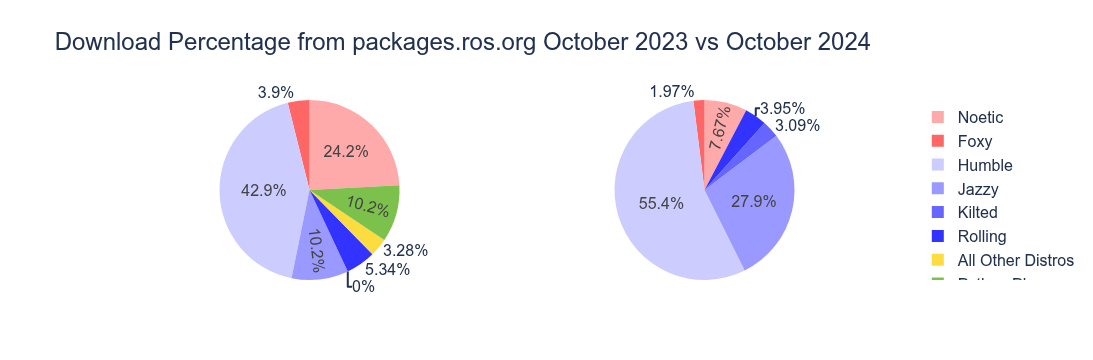

In [41]:
# Generate side by side plots of distros
temp = distro_df[distro_df[this_year]>=1].copy()
new_names = [a[0].upper()+a[1:] for a in temp["name"]]
print(new_names)
temp["name"] = pd.Series(data=new_names,copy=False,index=temp["name"].index)

new_row = pd.DataFrame(data=[{"name":"All Other Distros","2024":all_other_this,"2023":all_other_last},
                             {"name":"Python Pkgs","2024":everything_else_this,"2023":everything_else_last}])
temp = pd.concat([temp, new_row], ignore_index=True)
print(temp["name"])
print(temp)
print(temp[last_year].sum())
print(temp[this_year].sum())

title ={
    'text': "Plot Title",
    'y':0.9,
    'x':0.5,
    'xanchor': 'center',
    'yanchor': 'bottom'}

trace1 = go.Pie(values= temp[last_year], labels = temp["name"],domain=dict(x=[0, 0.5]),title="",sort= False)
trace2 = go.Pie(values= temp[this_year], labels = temp["name"],domain=dict(x=[0.5,1.0]),title="", sort=False)
layout = go.Layout(title="Download Percentage from packages.ros.org October 2023 vs October 2024")
data = [trace1,trace2]
fig = go.Figure(data=data, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E"
)

fig.update_traces(marker=dict(colors=['#FFAAAA','#FF6666','#CCCCFF','#9999FF',
                                      '#6666FF','#3333FF','#fcdc3f',"#7cc14b","#EE00FF","#FF00FF"]))

fig.show()


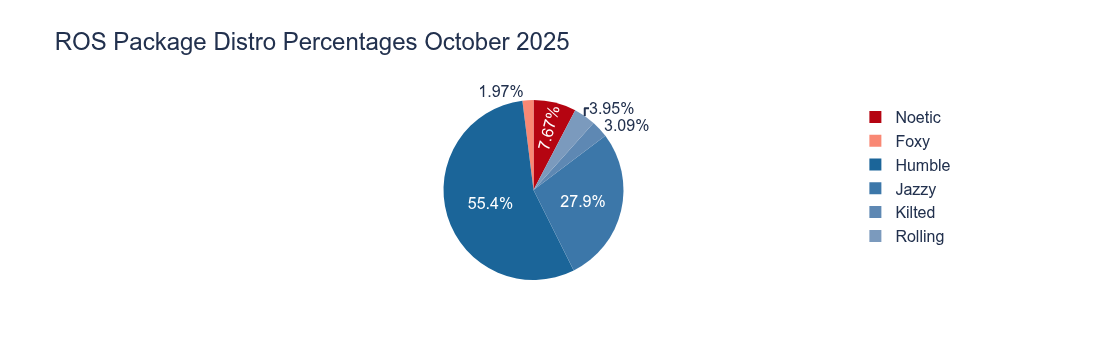

In [42]:
trace1 = go.Pie(values= temp[this_year], labels = temp["name"],title="",sort= False)
layout = go.Layout(title="ROS Package Distro Percentages {0} {1}".format(this_month,this_year))
fig = go.Figure(data=trace1, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E"
)

fig.update_traces(marker=dict(colors=["#b50411","#f98874","#1b6599","#3c77a9","#5e88b3","#7b9abd","#96acc7","#b0bed1"
,"#fdc6ba","#FFFF99"]))

fig.show()


In [ ]:
trace2 = go.Pie(values= temp[this_year], labels = temp["name"],title="",sort= False)
layout = go.Layout(title="ROS Package Downloads by Distro {0} {1}".format(this_month,this_year))
fig = go.Figure(data=trace2, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E"
)

fig.update_traces(marker=dict(colors=["#292f56",
"#412f4c",
"#592f43",
"#702f39",
"#882f30",
"#a02e26",
"#b82e1d",
"#cf2e13",
"#e72e0a",
"#ff2e00",]))

fig.show()


In [ ]:
# Download percentages by year
temp["diff"]=temp[this_year]-temp[last_year]
temp = arch_df[arch_os_df[this_year]>0.00001]

trace1 = go.Pie(values= temp[this_year], labels = temp["name"],domain=dict(x=[0.5, 1]),title=this_year)
trace2 = go.Pie(values= temp[last_year], labels = temp["name"],domain=dict(x=[0.0,0.5]),title=last_year)

layout = go.Layout(title="ROS Packages Downloaded By Architecture - {0} {1} vs {2} {3}".format(last_month,last_year,this_year,this_month))
data = [trace1, trace2]
fig = go.Figure(data=data, layout=layout)
fig.show()

In [ ]:
fig = px.bar(distro_df, x="name", y=["2023", "2022"], title="Wide-Form Input")
fig.show()

In [ ]:
fname = "../data/march_2020.txt"
stats_mar_2020 = process_package_dump(fname,"3/2020")
fname = "../data/march_2021.txt"
stats_mar_2021 = process_package_dump(fname,"3/2021")

joined_distro = join_stats([stats_mar_2020["distro"],stats_mar_2021["distro"]])
mar_distro_df = pd.DataFrame(data=joined_distro)
mar_distro_df.to_csv("march_distro.csv")
mar_distro_df.head()
stats_mar_2021 = process_package_dump(fname,"3/2021")

In [ ]:
temp = mar_distro_df[mar_distro_df["7/2021"]>0.5]

trace1 = go.Pie(values= temp["7/2020"], labels = temp["name"],domain=dict(x=[0.5,1.0]),title="7/2020")
trace2 = go.Pie(values= temp["7/2021"], labels = temp["name"],domain=dict(x=[0, 0.5]),title="7/2021")

layout = go.Layout(title="ROS Index Download Percentage: March 2020 vs. March 2021",)
data = [trace1, trace2]
fig = go.Figure(data=data, layout=layout)
fig.show()


In [ ]:
cd ../data/


In [ ]:
stats_this